In [35]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from scipy import sparse

print('Imports complete.')

Imports complete.


In [1360]:
def well_potential(x):
    return 1e6*(x<0) + 1e6*(x>1)

def added_potential(x):
    #return -.00001*(x)*(x-1)
    #return -0.00000001*np.sin(9*np.pi*x)
    return 1*0.0000001*(np.exp(-(x-.33)**2/(3e-4)) + np.exp(-(x-.66)**2/(3e-4)))

def well_potential_total(x):
    return well_potential(x) + added_potential(x)

def create_2nd_der(n_points):
    der2 = (1/n_points**2)*sparse.diags_array([1, -2, 1], offsets=[-1, 0, 1], shape=(n_points, n_points))
    return der2

def hamiltonian(n_points):
    der2 = create_2nd_der(n_points)
    xgrid = np.linspace(0,1,n_points)
    potential = well_potential_total(xgrid)
    potential_mat = sparse.diags_array(potential)
    return (-1*der2 + potential_mat)



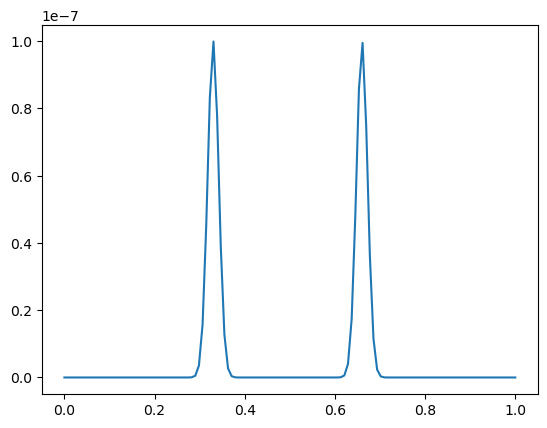

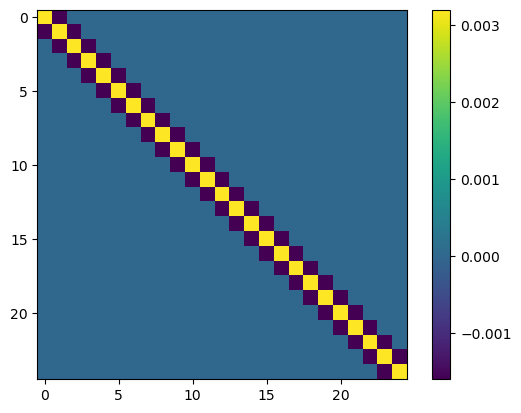

In [1362]:
potential_plot_n_points = 125
mat_n_points = 25
xgrid_temp = np.linspace(0,1,potential_plot_n_points)
plt.plot(xgrid_temp, well_potential_total(xgrid_temp))
plt.show()

plt.imshow(hamiltonian(mat_n_points).toarray())
plt.colorbar()
plt.show()


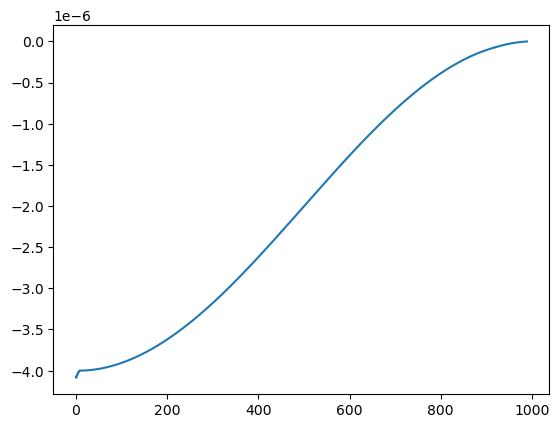

In [1364]:
n_points = 1000
k=int(9.9*n_points/10)
xgrid = np.linspace(0,1,n_points)
val,vec = sparse.linalg.eigsh(-hamiltonian(n_points),k)
plt.plot(np.real(val))#/np.max(np.abs(val)))
plt.show()

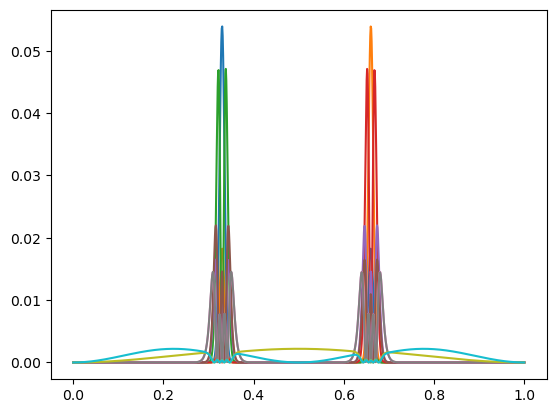

In [1372]:
n_vecs_plot = 10
for i in range(n_vecs_plot):
    plt.plot(xgrid,np.abs(vec[:,i])**2)
plt.show()

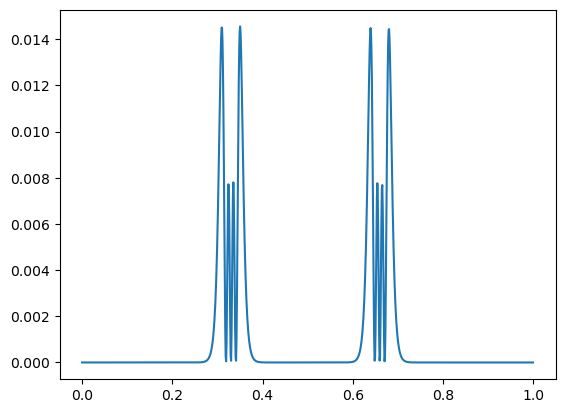

In [1388]:
plt.plot(xgrid,np.abs(vec[:,7])**2)

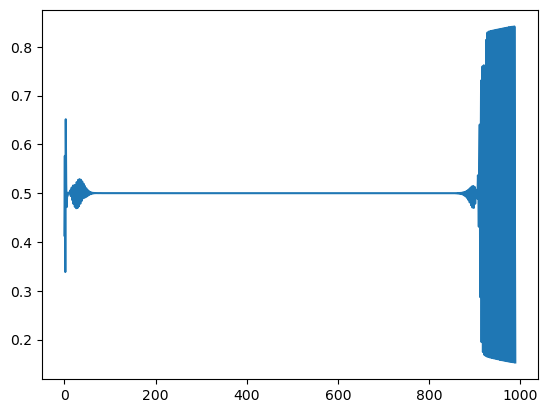

In [1392]:
mean_positions = np.zeros(k)
for i in range(k):
    mean_positions[i] = np.sum(vec[:,i]*xgrid*vec[:,i])

plt.plot(mean_positions)

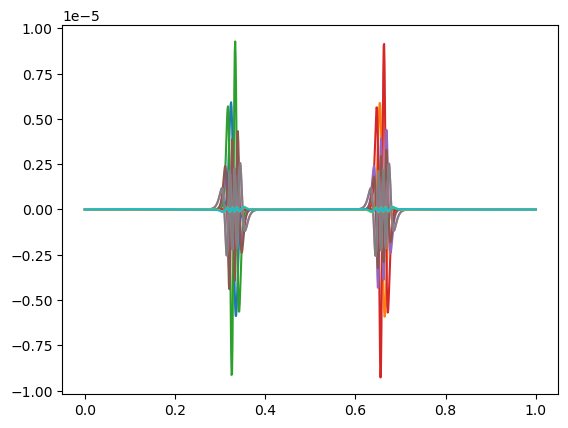

In [1424]:
def fwd_dif(n_points):
    return (1/n_points)*sparse.diags_array([-1,1], offsets=[0, 1], shape=(n_points, n_points))

fwd_dif_mat = fwd_dif(n_points)

for i in range(n_vecs_plot):
    plt.plot(xgrid, (vec[:,i]*fwd_dif_mat@vec[:,i]))

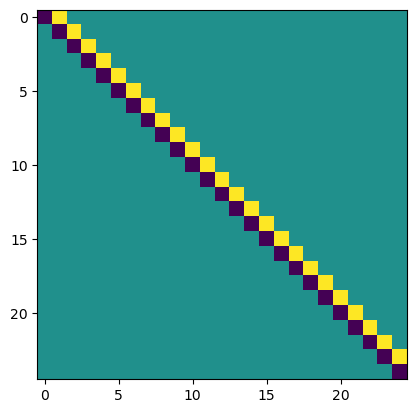